In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score, precision_score
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import ADASYN, SMOTE

SEED = 97

In [2]:
df = pd.read_csv("creditcard.csv", sep=",")

In [3]:
# First five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# Missing values per column
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 1081


In [8]:
# Handle duplicate rows
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Duplicate rows removed: {before - after}")
print(f"Current shape: {df.shape}")

Duplicate rows removed: 1081
Current shape: (283726, 31)


In [9]:
# Class counts and percentages
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': class_counts, 'percent': class_pct.round(3)}))
print(f"\nImbalance ratio: 1 fraud per {class_counts[0] / class_counts[1]:.0f} legit transactions")


        count  percent
Class                 
0      283253   99.833
1         473    0.167

Imbalance ratio: 1 fraud per 599 legit transactions


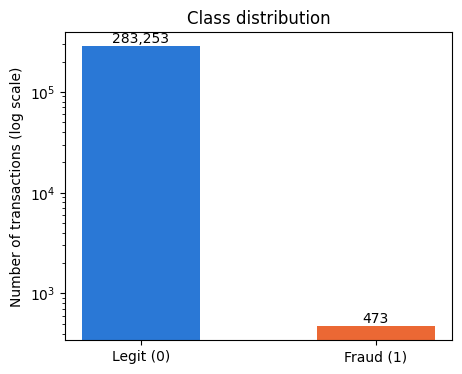

In [10]:
# Class distribution plot (log scale so the fraud bar is visible)
counts = df['Class'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['#2a78d6', '#eb6834'], width=0.5)
plt.yscale('log')
plt.ylabel('Number of transactions (log scale)')
plt.title('Class distribution')
for i, n in enumerate(counts.values):
    plt.text(i, n, f'{n:,}', ha='center', va='bottom')
plt.show()


In [11]:
# Summary of Amount for each class
df.groupby('Class')['Amount'].describe()


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


# Model Training and Cross Validation

In [12]:
#split into x and y - 30 is the class column
X = df.drop('Class', axis=1)
Y = df['Class']

print(f"Training shape: {X.shape}, Training head:\n{X.head()}")
print(f"Target shape: {Y.shape}, Target head:\n{Y.head()}")

Training shape: (283726, 30), Training head:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  

In [ ]:
#FOR Notes here, we have SMOTE, ADASYN and Baseline model.
# Since all the action would be in the pipeline, I'll define the difference by the different code cells.
SVM_model = LinearSVC(random_state=SEED)

In [17]:
#SMOTE PIPELINE

smote_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("SMOTE", SMOTE(random_state=SEED)),
    ("SVM_model", SVM_model)
])

smote_f1Scores = []
smote_recall = []
smote_precision = []
smote_accuracy = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
    smote_pipeline.fit(X_train, y_train)
    
    y_pred = smote_pipeline.predict(X_test)
    smote_accuracy.append(accuracy_score(y_test, y_pred))
    smote_f1Scores.append(f1_score(y_test, y_pred))
    smote_recall.append(recall_score(y_test, y_pred))
    smote_precision.append(precision_score(y_test, y_pred))

print('\nSMOTE')
print("Recall:", [round(x, 3) for x in smote_recall])
print("Precision:", [round(x, 3) for x in smote_precision])
print("Accuracy scores:", [round(x, 3) for x in smote_accuracy])
print("F1 scores:", [round(x, 3) for x in smote_f1Scores])


SMOTE
Recall: [0.809, 0.894, 0.957, 0.938, 0.958, 0.833, 0.872, 0.894, 0.936, 0.894]
Precision: [0.071, 0.062, 0.071, 0.063, 0.071, 0.066, 0.061, 0.067, 0.071, 0.07]
Accuracy scores: [0.982, 0.977, 0.979, 0.976, 0.979, 0.98, 0.977, 0.979, 0.98, 0.98]
F1 scores: [0.131, 0.115, 0.132, 0.119, 0.131, 0.122, 0.114, 0.125, 0.133, 0.13]


In [16]:
#ADASYN PIPELINE

adasyn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ADASYN", ADASYN(random_state=SEED)),
    ("SVM_model", SVM_model)
])

adasyn_f1Scores = []
adasyn_recall = []
adasyn_precision = []
adasyn_accuracy = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
    adasyn_pipeline.fit(X_train, y_train)
    
    y_pred = adasyn_pipeline.predict(X_test)
    adasyn_accuracy.append(accuracy_score(y_test, y_pred))
    adasyn_f1Scores.append(f1_score(y_test, y_pred))
    adasyn_recall.append(recall_score(y_test, y_pred))
    adasyn_precision.append(precision_score(y_test, y_pred))

print('\nADASYN')
print("Recall:", [round(x, 3) for x in adasyn_recall])
print("Precision:", [round(x, 3) for x in adasyn_precision])
print("Accuracy scores:", [round(x, 3) for x in adasyn_accuracy])
print("F1 scores:", [round(x, 3) for x in adasyn_f1Scores])


ADASYN
Recall: [0.872, 0.936, 0.936, 0.938, 0.979, 0.875, 0.915, 0.915, 0.957, 0.957]
Precision: [0.016, 0.018, 0.017, 0.018, 0.018, 0.017, 0.019, 0.017, 0.017, 0.017]
Accuracy scores: [0.911, 0.916, 0.912, 0.912, 0.91, 0.915, 0.922, 0.915, 0.907, 0.91]
F1 scores: [0.032, 0.036, 0.034, 0.035, 0.035, 0.034, 0.037, 0.034, 0.033, 0.034]


In [18]:
#BASELINE PIPELINE

baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("SVM_model", SVM_model)
])

baseline_f1Scores = []
baseline_recall = []
baseline_precision = []
baseline_accuracy = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
    baseline_pipeline.fit(X_train, y_train)
    
    y_pred = baseline_pipeline.predict(X_test)
    baseline_accuracy.append(accuracy_score(y_test, y_pred))
    baseline_f1Scores.append(f1_score(y_test, y_pred))
    baseline_recall.append(recall_score(y_test, y_pred))
    baseline_precision.append(precision_score(y_test, y_pred))

print('\nBASELINE')
print("Recall:", [round(x, 3) for x in baseline_recall])
print("Precision:", [round(x, 3) for x in baseline_precision])
print("Accuracy scores:", [round(x, 3) for x in baseline_accuracy])
print("F1 scores:", [round(x, 3) for x in baseline_f1Scores])


BASELINE
Recall: [0.489, 0.596, 0.745, 0.562, 0.604, 0.521, 0.596, 0.404, 0.596, 0.596]
Precision: [0.821, 0.903, 0.854, 0.931, 0.829, 0.926, 0.903, 0.792, 0.848, 0.933]
Accuracy scores: [0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999, 0.999]
F1 scores: [0.613, 0.718, 0.795, 0.701, 0.699, 0.667, 0.718, 0.535, 0.7, 0.727]


### WHATS GOING ON THOUGH???
#### how is the baseline model performing better?

# RANDOM FOREST WITHOUT SCALING???

In [25]:
#RANDOM FOREST MODEL
RF_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED, max_depth=20)

In [26]:
#SMOTE PIPELINE

rf_smote_pipeline = Pipeline([
    ("SMOTE", SMOTE(random_state=SEED)),
    ("RF_model", RF_model)
])

rf_smote_f1Scores = []
rf_smote_recall = []
rf_smote_precision = []
rf_smote_accuracy = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
    rf_smote_pipeline.fit(X_train, y_train)
    
    y_pred = rf_smote_pipeline.predict(X_test)
    rf_smote_accuracy.append(accuracy_score(y_test, y_pred))
    rf_smote_f1Scores.append(f1_score(y_test, y_pred))
    rf_smote_recall.append(recall_score(y_test, y_pred))
    rf_smote_precision.append(precision_score(y_test, y_pred))

print('\nRF SMOTE')
print("Recall:", [round(x, 3) for x in rf_smote_recall])
print("Precision:", [round(x, 3) for x in rf_smote_precision])
print("Accuracy scores:", [round(x, 3) for x in rf_smote_accuracy])
print("F1 scores:", [round(x, 3) for x in rf_smote_f1Scores])


RF SMOTE
Recall: [0.681, 0.83, 0.894, 0.896, 0.896, 0.771, 0.83, 0.809, 0.851, 0.787]
Precision: [0.821, 0.83, 0.84, 0.811, 0.915, 0.86, 0.867, 0.826, 0.8, 0.804]
Accuracy scores: [0.999, 0.999, 1.0, 0.999, 1.0, 0.999, 1.0, 0.999, 0.999, 0.999]
F1 scores: [0.744, 0.83, 0.866, 0.851, 0.905, 0.813, 0.848, 0.817, 0.825, 0.796]


In [27]:
# RF ADASYN PIPELINE

rf_adasyn_pipeline = Pipeline([
    ("ADASYN", ADASYN(random_state=SEED)),
    ("RF_model", RF_model)
])

rf_adasyn_f1Scores = []
rf_adasyn_recall = []
rf_adasyn_precision = []
rf_adasyn_accuracy = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
    rf_adasyn_pipeline.fit(X_train, y_train)
    
    y_pred = rf_adasyn_pipeline.predict(X_test)
    rf_adasyn_accuracy.append(accuracy_score(y_test, y_pred))
    rf_adasyn_f1Scores.append(f1_score(y_test, y_pred))
    rf_adasyn_recall.append(recall_score(y_test, y_pred))
    rf_adasyn_precision.append(precision_score(y_test, y_pred))

print('\nRF ADASYN')
print("Recall:", [round(x, 3) for x in rf_adasyn_recall])
print("Precision:", [round(x, 3) for x in rf_adasyn_precision])
print("Accuracy scores:", [round(x, 3) for x in rf_adasyn_accuracy])
print("F1 scores:", [round(x, 3) for x in rf_adasyn_f1Scores])


RF ADASYN
Recall: [0.681, 0.83, 0.894, 0.875, 0.896, 0.771, 0.809, 0.851, 0.851, 0.787]
Precision: [0.842, 0.812, 0.824, 0.857, 0.915, 0.86, 0.905, 0.833, 0.816, 0.841]
Accuracy scores: [0.999, 0.999, 1.0, 1.0, 1.0, 0.999, 1.0, 0.999, 0.999, 0.999]
F1 scores: [0.753, 0.821, 0.857, 0.866, 0.905, 0.813, 0.854, 0.842, 0.833, 0.813]


In [28]:
# RF BASELINE PIPELINE

rf_baseline_pipeline = Pipeline([
    ("RF_model", RF_model)
])

rf_baseline_f1Scores = []
rf_baseline_recall = []
rf_baseline_precision = []
rf_baseline_accuracy = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for train_index, test_index in skf.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
    rf_baseline_pipeline.fit(X_train, y_train)
    
    y_pred = rf_baseline_pipeline.predict(X_test)
    rf_baseline_accuracy.append(accuracy_score(y_test, y_pred))
    rf_baseline_f1Scores.append(f1_score(y_test, y_pred))
    rf_baseline_recall.append(recall_score(y_test, y_pred))
    rf_baseline_precision.append(precision_score(y_test, y_pred))

print('\nRF BASELINE')
print("Recall:", [round(x, 3) for x in rf_baseline_recall])
print("Precision:", [round(x, 3) for x in rf_baseline_precision])
print("Accuracy scores:", [round(x, 3) for x in rf_baseline_accuracy])
print("F1 scores:", [round(x, 3) for x in rf_baseline_f1Scores])


RF BASELINE
Recall: [0.617, 0.787, 0.872, 0.833, 0.875, 0.625, 0.809, 0.766, 0.766, 0.809]
Precision: [0.935, 0.974, 0.932, 0.976, 0.977, 1.0, 0.927, 0.923, 0.9, 0.95]
Accuracy scores: [0.999, 1.0, 1.0, 1.0, 1.0, 0.999, 1.0, 1.0, 0.999, 1.0]
F1 scores: [0.744, 0.871, 0.901, 0.899, 0.923, 0.769, 0.864, 0.837, 0.828, 0.874]
